<a href="https://colab.research.google.com/github/ValeriiSlynko/IT-STEP-Practice/blob/master/Practice_Pandas/HmWrk3_Pandas(Pipeline%20%26%20Tree).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# підвантажуємо бібліотеки для роботи
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# завантажуємо dataset
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/House_Rent_Dataset.csv", index_col="Unnamed: 0")

ІНФОРМАЦІЯ ПРО ДАНІ

**Posted On** -- Дата публікації

**BHK** -- Кількість спалень, вітальня та кухня.

**Rent** -- Вартість оренди будинку чи квартири.

**Size** -- Розмір будинку чи квартири у квадратних футах.

**Floor** -- Поверх, на якому розташоване житло, та загальна кількість поверхів у будинку (наприклад: перший із 2, третій із 5 тощо).

**Area Type** -- Розрахунок площі житла (загальна площа, корисна площа або площа забудови).

**Area Locality** -- Locality of the Houses/Apartments/Flats.

**City** -- Місто, де розташоване житло.

**Furnishing Status** -- Стан меблювання (повністю мебльоване, частково мебльоване або без меблів).

**Tenant Preferred** -- Тип орендаря, якому надає перевагу власник або агент.

**Bathroom** -- Кількість ванних кімнат.

**Point of Contact** -- До кого звертатися за додатковою інформацією щодо житла.

# Завдання 1 Очистіть дані від викидів/ Отримайте ознаки та цільову змінну(X, y) / Розділіть дані на тренувальні та тестові

*Очищаємо дані від икидів*

In [3]:
# визначаємо кількість рядків та стовпчиків
rows, columns = df.shape
print(f"Таблиця має '{rows}' рядків та '{columns}' стовпчиків/колнок")

Таблиця має '4746' рядків та '12' стовпчиків/колнок


In [4]:
# отримуємо назви всіх стовпчиків та типи даних
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Posted On          4379 non-null   object 
 1   BHK                4342 non-null   float64
 2   Rent               4369 non-null   float64
 3   Size               4402 non-null   float64
 4   Floor              4380 non-null   object 
 5   Area Type          4390 non-null   object 
 6   Area Locality      4347 non-null   object 
 7   City               4388 non-null   object 
 8   Furnishing Status  4395 non-null   object 
 9   Tenant Preferred   4372 non-null   object 
 10  Bathroom           4387 non-null   float64
 11  Point of Contact   4372 non-null   object 
dtypes: float64(4), object(8)
memory usage: 482.0+ KB


In [5]:
# дивимось кількість пропусків у стовпчиків
df.isna().sum()

,0
Posted On,367
BHK,404
Rent,377
Size,344
Floor,366
Area Type,356
Area Locality,399
City,358
Furnishing Status,351
Tenant Preferred,374


In [6]:
# показуємо табличний dataset з першими 20 рядками
df.head(20)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2.0,10000.0,1100.0,Ground out of 2,NaN,NaN,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
1,2022-05-13,2.0,20000.0,800.0,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1.0,NaN
2,2022-05-16,2.0,17000.0,1000.0,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1.0,Contact Owner
3,2022-07-04,2.0,10000.0,800.0,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1.0,Contact Owner
4,NaN,2.0,7500.0,850.0,1 out of 2,Carpet Area,NaN,Kolkata,Unfurnished,Bachelors,1.0,Contact Owner
5,2022-04-29,2.0,7000.0,600.0,Ground out of 1,Super Area,Thakurpukur,Kolkata,Unfurnished,Bachelors/Family,2.0,Contact Owner
6,2022-06-21,2.0,10000.0,700.0,Ground out of 4,Super Area,Malancha,Kolkata,Unfurnished,Bachelors,NaN,Contact Agent
7,2022-06-21,1.0,5000.0,250.0,1 out of 2,Super Area,Malancha,NaN,Unfurnished,Bachelors,1.0,Contact Agent
8,2022-06-07,2.0,26000.0,800.0,1 out of 2,Carpet Area,"Palm Avenue Kolkata, Ballygunge",Kolkata,Unfurnished,Bachelors,2.0,Contact Agent
9,2022-06-20,2.0,NaN,1000.0,1 out of 3,Carpet Area,Natunhat,Kolkata,Semi-Furnished,Bachelors/Family,2.0,Contact Owner


Гістограми для всіх числових стовпчиків

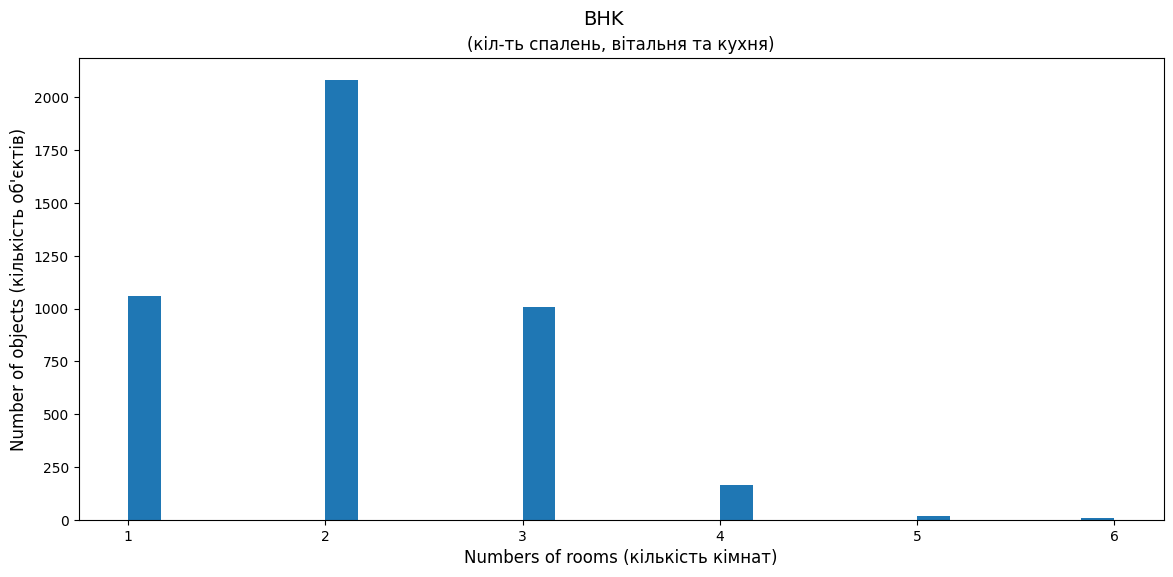

In [7]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = df['BHK'].plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('BHK', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(кіл-ть спалень, вітальня та кухня)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Numbers of rooms (кількість кімнат)', fontsize=12) # Підпис горизонтальної осі X (значення BHK / кількість кімнат)
ax.set_ylabel("Number of objects (кількість об'єктів)", fontsize=12) # Підпис вертикальної осі Y (кількість квартир у датасеті)
plt.show() # Виводимо остаточно сформований графік на екран.

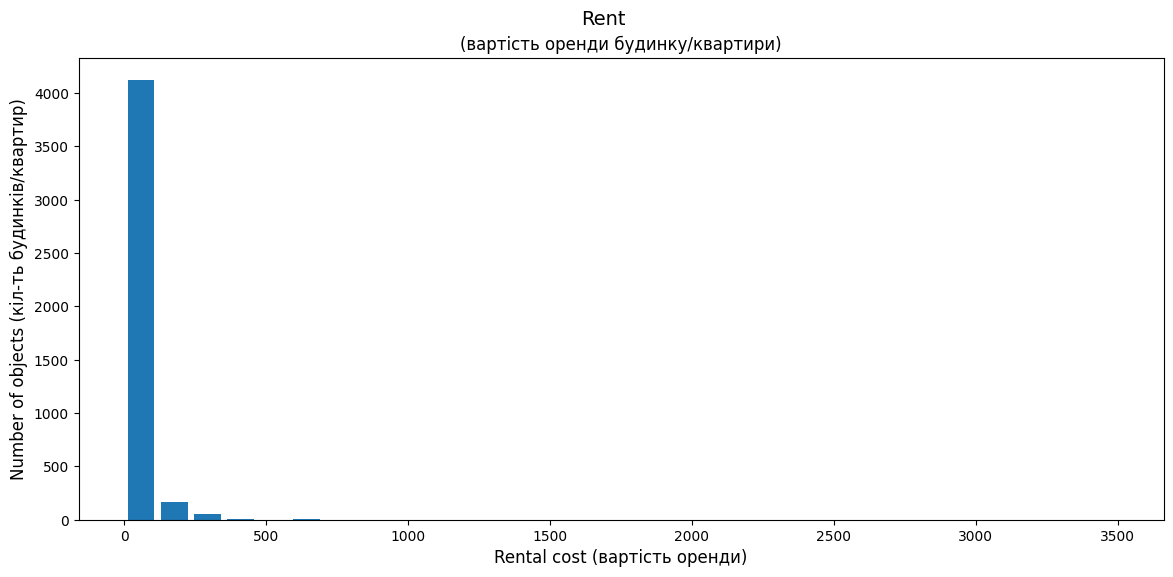

In [8]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = (df['Rent']/1000).plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)
      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('Rent', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(вартість оренди будинку/квартири)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Rental cost (вартість оренди)', fontsize=12) # Підпис горизонтальної осі X
ax.set_ylabel('Number of objects (кіл-ть будинків/квартир)', fontsize=12) # Підпис вертикальної осі Y
plt.show() # Виводимо остаточно сформований графік на екран.

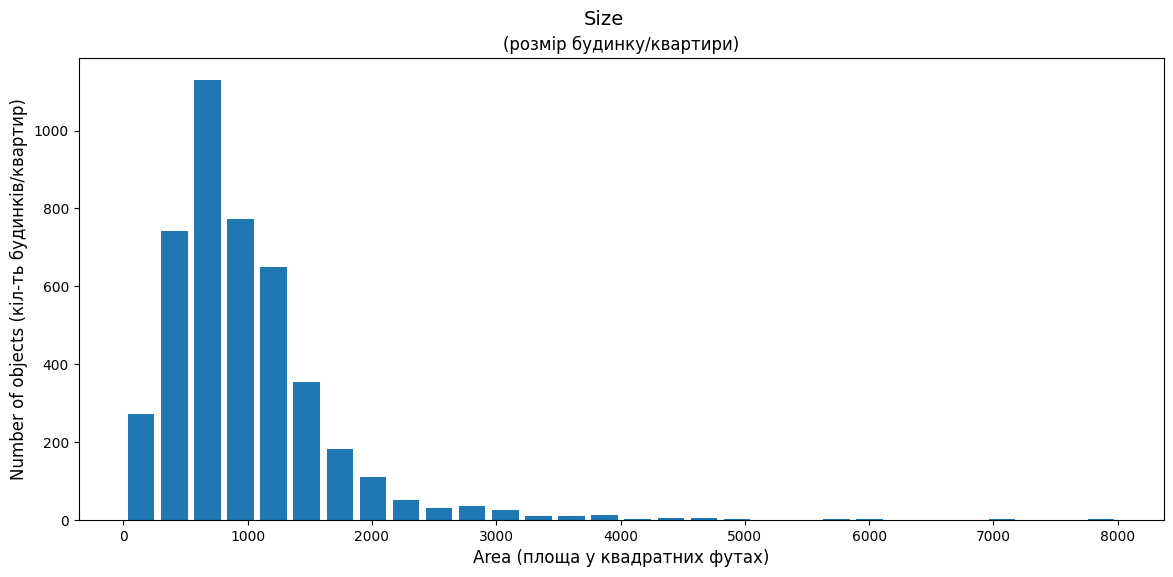

In [9]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = (df['Size']).plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)
      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('Size', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(розмір будинку/квартири)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Area (площа у квадратних футах)', fontsize=12) # Підпис горизонтальної осі X
ax.set_ylabel('Number of objects (кіл-ть будинків/квартир)', fontsize=12) # Підпис вертикальної осі Y
plt.show() # Виводимо остаточно сформований графік на екран.

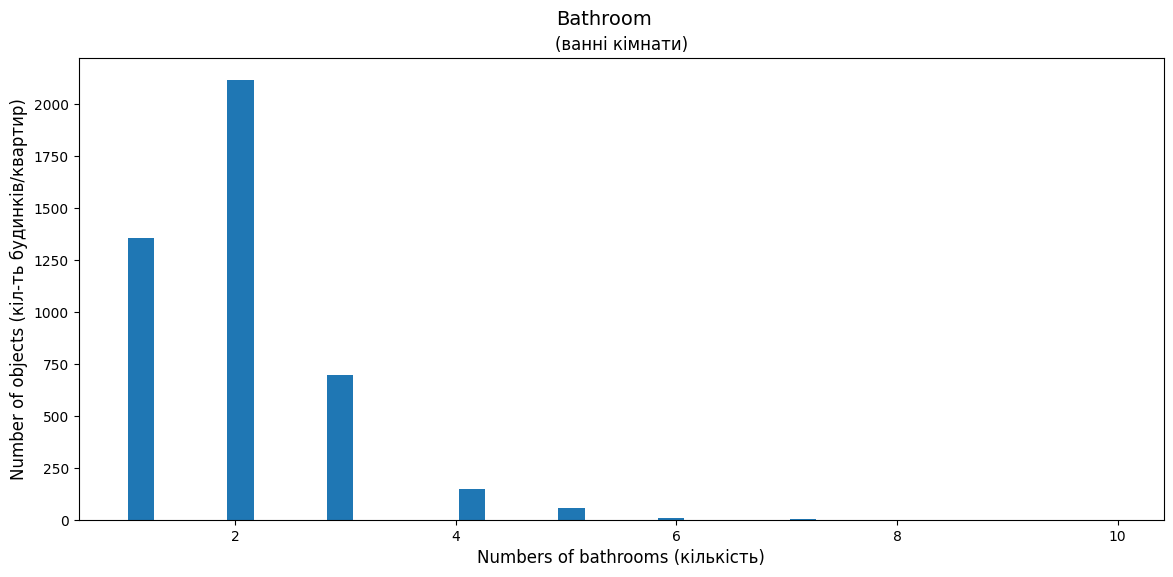

In [10]:
# виводимо гісторгаму BHK(кількість спалень, вітальня та кухня)
ax = (df['Bathroom']).plot(
      kind='hist',     # тип діаграми hist(гістограма)
      bins=30,         # кількість стовпчиків
      figsize=(14,6),  # розмір зображення(ширина,висота в дюймах)
      rwidth=0.8       # ширина стовпчиків(зараз 80%)
      )


plt.suptitle('Bathroom', fontsize=14, y=0.96) # Назва самого графіка (заголовок)
ax.set_title('(ванні кімнати)', fontsize=12) # Підзаголовок нижче (12 розмір шрифту)
ax.set_xlabel('Numbers of bathrooms (кількість)', fontsize=12) # Підпис горизонтальної осі X
ax.set_ylabel('Number of objects (кіл-ть будинків/квартир)', fontsize=12) # Підпис вертикальної осі Y
plt.show() # Виводимо остаточно сформований графік на екран.

Ящики з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

Text(0.5, 0, 'BHK (кількість кімнат)')

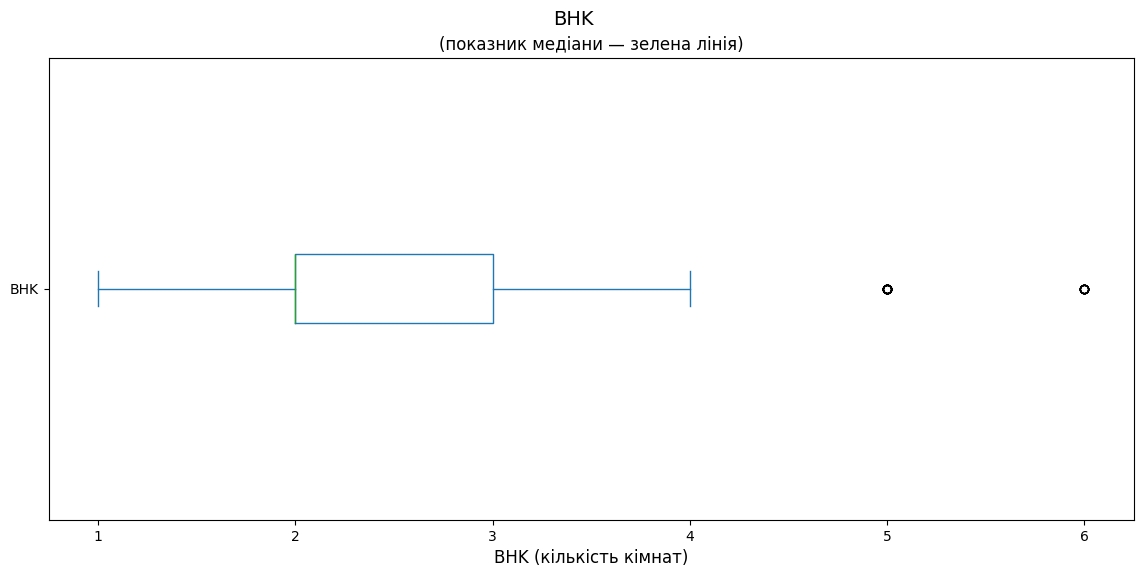

In [11]:
# малюємо ящик з вусами BHK(кількість спалень, вітальня та кухня)
ax = df['BHK'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('BHK', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('BHK (кількість кімнат)', fontsize=12)

In [12]:
# Застосовуємо фільтри і для Rent, і для Size одночасно:
mask = (df['Rent'] < 0.2 * 1e6) & (df['Size'] < 5000)
df_filter = df[mask]

Text(0.5, 0, 'Rental cost (вартість оренди)')

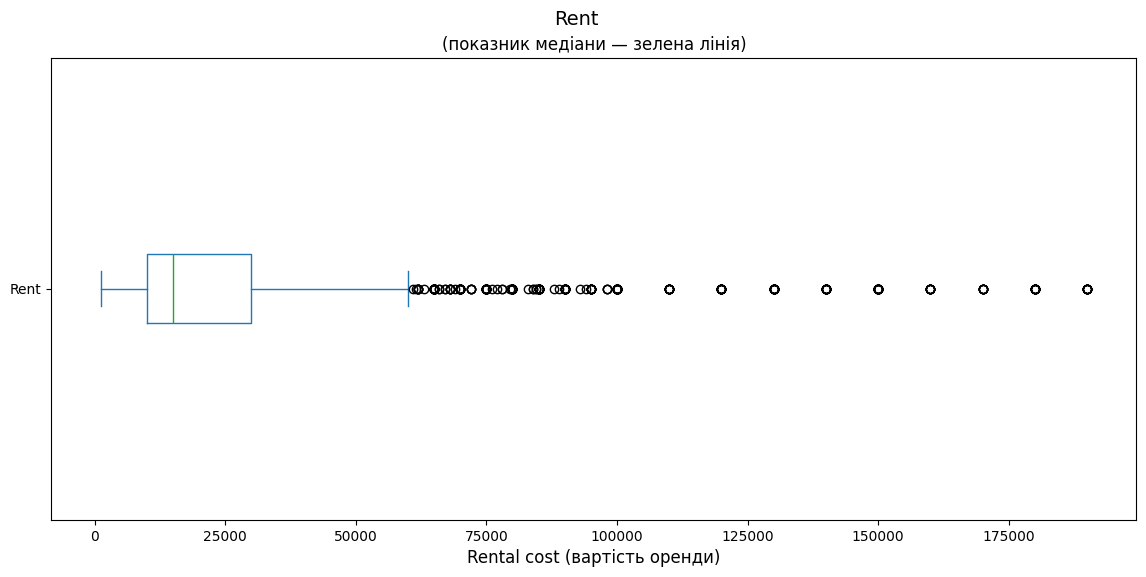

In [13]:
# малюємо ящик з вусами Rent(вартість оренди)
ax = df_filter['Rent'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('Rent', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Rental cost (вартість оренди)', fontsize=12)

In [14]:
# робимо корегування/видалення викидів
mask = df['Size'] < 5000
mask.sum()

np.int64(4397)

In [15]:
# записуємо у змінну відфільтрованих даних
# df_filter = df[mask]

Text(0.5, 0, 'Area (площа у квадратних футах)')

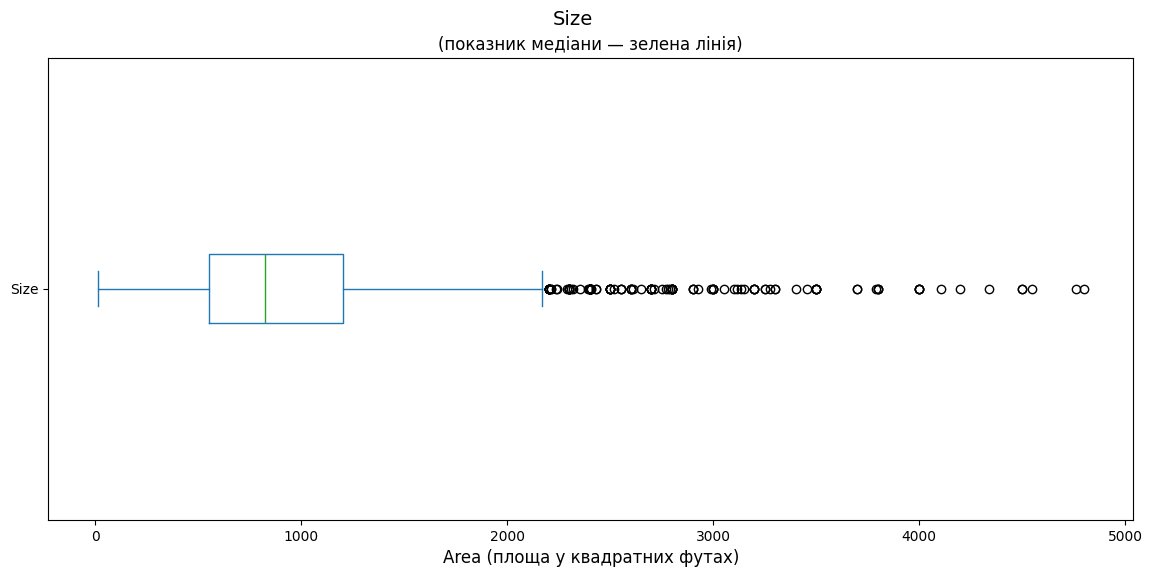

In [16]:
# малюємо ящик з вусами Size(площа)
ax = df_filter['Size'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('Size', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Area (площа у квадратних футах)', fontsize=12)

Text(0.5, 0, 'Numbers of bathrooms (кількість)')

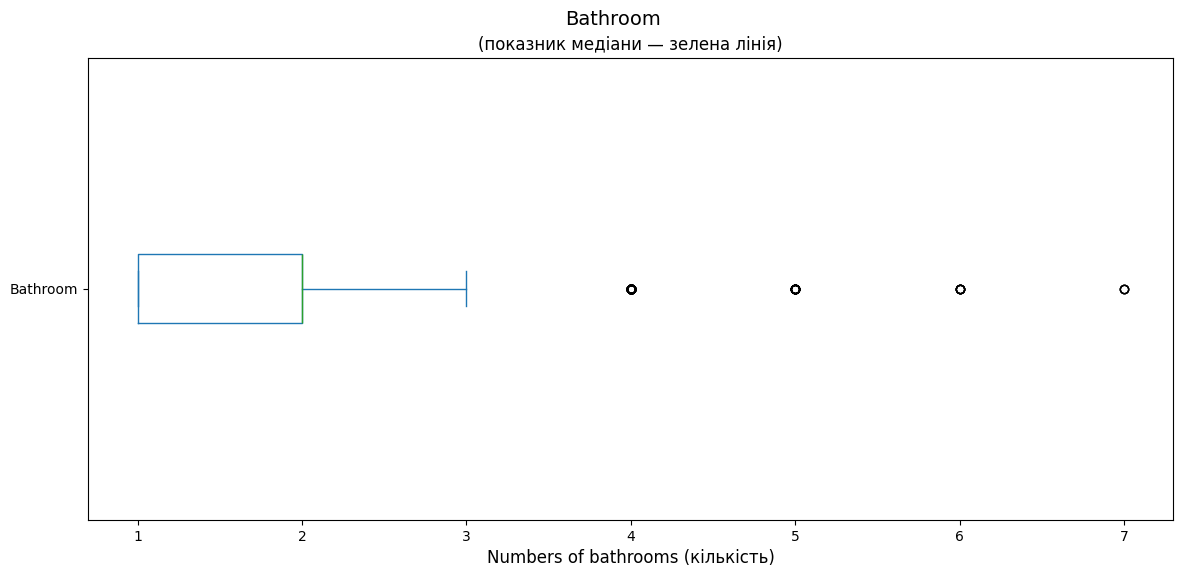

In [17]:
# малюємо ящик з вусами Bathroom(кількість ванних кімнат)
ax = df_filter['Bathroom'].plot(kind='box', vert=False, figsize=(14, 6))

# Додаємо заголовки та підписи
plt.suptitle('Bathroom', fontsize=14, y=0.96)
ax.set_title('(показник медіани — зелена лінія)', fontsize=12)
ax.set_xlabel('Numbers of bathrooms (кількість)', fontsize=12)

Отримуємо ознаки та цільову змінну(X, y)

In [18]:
# y = df['Rent']
# X = df.drop(columns='Rent')
# X

У стовпчику **Rent** є **377** пропущених значень (*NaN*). Якщо в ознаках '**X**' пропуски легко заповнюються через пайплайн (SimpleImputer), то в цільовій змінній '**y**' пропуски залишати не можна, оскільки модель не може навчатися на об'єктах, де невідома відповідь.
 ОТЖЕ, перед розділенням даних на ТРЕНУВАЛЬНІ та ТЕСТОВІ у функію train_test_split: потрібно видалити рядки з пропущеними значеннями, тобто де **Rent** дорівнює *NaN*

In [19]:
# 1. Видаляємо NaN з відфільтрованого датасету
df_clean = df_filter.dropna(subset=['Rent']).copy()

# 2. Формуємо X та y СТРОГО з очищеного df_clean
y = df_clean['Rent']
X = df_clean.drop(columns='Rent')

# Розділюємо дані на тренувальні та тестові

In [20]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Розподіл даних на тренувальну (80%) та тестову (20%) вибірки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% даних іде на тест, 80% на тренування
    random_state=42,    # Фіксація випадкового стану для відтворюваності
    )
# -де ' train_test_split ' - назва функції

In [21]:
X_train.shape

(3167, 11)

In [22]:
X_test.shape

(792, 11)

In [23]:
y_train.shape

(3167,)

In [24]:
y_test.shape

(792,)

# Завдання 2
Створіть Pipeline для обробки даних числових та категоріальних даних

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Визначення числових та категоріальних колонок
num_features = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_features = X_train.select_dtypes(include=['object', 'category']).columns

# Пайплайн для числових даних
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

# Пайплайн для категоріальних даних
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore',sparse_output=False))
])

# Об'єднання в один препроцесор
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

# Застосування до тренувальних та тестових даних
X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

* *Вивід ЧИСЛОВИХ СТОВПЧИКІВ 'num_features' для ознайомлення*

In [26]:
num_features

Index(['BHK', 'Size', 'Bathroom'], dtype='object')

* *Вивід СТОВПЧИКІВ із 'str' рядками -"num_features" для ознайомлення*

In [27]:
cat_features

Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='object')

* *Вивід 'preprocessor' (об'єднання num_pipeline & cat_pipeline) на екран для ознайомлення*

In [28]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['BHK', 'Size', 'Bathroom'], dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Point of Contact'],
      dtype='object'))])

# Завдання 3
Об'єднайте препроцесор з деревом рішень в один пайплайн

Об'єднуємо препроцесор та модель дерева рішень у єдиний фінальний пайплайн.
Для цього використовується клас **Pipeline** з **sklearn.pipeline**

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# 1. Створюємо модель дерева рішень для регресії
tree_model = DecisionTreeRegressor(
    max_depth=7,          # Обмеження глибини дерева (щоб уникнути перенавчання)
    min_samples_leaf=5,   # Мінімальна кількість об'єктів у листі
    random_state=42       # Фіксація випадковості
)

# 2. Об'єднуємо preprocessor та tree_model в один підсумковий Pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Наш препроцесор із Завдання 2
    ('model', tree_model)           # Модель дерева
])

# 3. Навчаємо увесь пайплайн на сирих тренувальних даних (X_train, y_train)
final_pipeline.fit(X_train, y_train)

print("Фінальний пайплайн успішно створено та навчено!")

Фінальний пайплайн успішно створено та навчено!


# Завдання 4
Виведіть основні метрики моделі

* ***MAE (Mean Absolute Error — Середня абсолютна помилка)***
  Що вимірює: Середнє значення відхилення прогнозованої ціни від реальної.
  Як розуміти результат: Якщо, наприклад, MAE = 2.50$, це означає, що модель у середньому помиляється на 2.50 одиниці (тисяч доларів, гривень тощо) у будь-який бік — як у більший, так і в менший.
* *MSE (Mean Squared Error — Середня квадратична помилка)*
  Що вимірює: Середнє  значення квадратів усіх помилок.
  Як розуміти результат: Оскільки помилка підноситься до квадрата, ця метрика дуже сильно покарання (штрафує) модель за великі промахи.
  **Якщо модель помилилася на 2 штраф буде 4, а якщо на 10 штраф стане 100.**
* *RMSE (Root Mean Squared Error — Корінь із середньої квадратичної помилки)*
  Що вимірює: Квадратний корінь із MSE. Як розуміти результат: Повертає значення метрики назад у звичайні одиниці вимірювання ціни (як і MAE). Порівняння з MAE: Якщо RMSE дуже близький до MAE, модель помиляється рівномірно.Якщо RMSE значно більший за MAE, це сигнал, що у даних є поодинокі дуже великі помилки (викиди), де дерево сильно схибило.
* *R² Score (Коефіцієнт детермінації) *
  Що вимірює: Якість моделі у відсотках/частках порівняно з простою підказкою «брати завжди середню ціну».
  Як розуміти результат:
  1.0 ідеальна модель прогнозує абсолютну точність без помилок
 (85%) — відмінний результат. Модель пояснює 85% закономірностей у цінах.
  0.0 модель працює так само як якщо б ти просто видавав середнє арифметичне значення ціни для всіх об'єктів.
  Меньше — модель працює гірше за випадкове вгадування.*

In [30]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Отримуємо прогнози для тестової вибірки
y_pred = final_pipeline.predict(X_test)

# 2. Розраховуємо метрики
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)  # Беремо корінь від MSE
r2 = r2_score(y_test, y_pred)

# 3. Виводимо результати з позначенням грошових одиниць (Індійська рупія — ₹ / INR)
print("=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (Оренда житла в Індії) ===")
print(f"MAE  (Mean Absolute Error): {mae:.2f} ₹ (середня помилка в рупіях)")
print(f"MSE  (Mean Squared Error):  {mse:.2f} ₹² (квадратична помилка)")
print(f"RMSE (Root MSE):            {rmse:.2f} ₹ (помилка з урахуванням викидів)")
print(f"R² Score:                   {r2:.4f} ({r2*100:.2f}% поясненої дисперсії)")

=== ОСНОВНІ МЕТРИКИ МОДЕЛІ (Оренда житла в Індії) ===
MAE  (Mean Absolute Error): 9793.26 ₹ (середня помилка в рупіях)
MSE  (Mean Squared Error):  330299094.86 ₹² (квадратична помилка)
RMSE (Root MSE):            18174.13 ₹ (помилка з урахуванням викидів)
R² Score:                   0.6823 (68.23% поясненої дисперсії)


# Завдання 5
Змініть параметри моделі та попробуйте покращити результат та натренуйте його

РЕЗУЛЬТАТ === ОСНОВНІ МЕТРИКИ МОДЕЛІ (Оренда житла в Індії) ===
  MAE  (Mean Absolute Error): 15232.48 ₹ (середня помилка в рупіях)
  MSE  (Mean Squared Error):  1417408883.82 ₹² (квадратична помилка)
  RMSE (Root MSE):            37648.49 ₹ (помилка з урахуванням викидів)
  R² Score:                   0.5020 (50.20% поясненої дисперсії)

• Із ОСНОВНИХ МЕТРИК МОДЕЛІ (Оренда житла в Індії) видно, що дані мають не найкращий вигляд, хоча залишаються усередненими ($R^2 \approx 50.2\%$). Похибка MAE складає близько 15 232 ₹, що є помірним відхиленням для середнього сегмента оренди.

• Головною причиною високих значень MSE та RMSE є наявність екстремальних викидів (наддорога елітна нерухомість із вартістю понад 100 000 – 400 000 ₹), які суттєво викривляють метрики, адже ці помилки підносяться до квадрата.

• Для покращення точності моделі в Завданні 5 доцільно провести додаткове очищення датасету від екстремальних аномалій за допомогою Boxplot (або 98-го квантиля) та використати GridSearchCV для підбору оптимальної глибини дерева рішень.

* **ВАЖЛИВО:** Для суттєвого покращення результатів, усі подальші зміни, підбір гіперпараметрів та фінальне тренування моделі будуть проводитися **з урахуванням попереднього очищення даних від екстремальних викидів**. Тільки застосувавши ці дії, ми зможемо розрахувати набагато кращі та адекватніші значення метрик.

In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Створюємо модель дерева з обмеженням перенавчання (гіперпараметри)
tuned_tree = DecisionTreeRegressor(
    max_depth=8,          # обмеження глибини дерева (запобігає заучуванню шуму)
    min_samples_split=10,   # мінімальна кількість об'єктів у вузлі для його поділу
    min_samples_leaf=4,     # мінімальна кількість об'єктів у фінальному листі
    random_state=42
)

# 2. Збираємо новий пайплайн з підібраною моделлю
tuned_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', tuned_tree)
])

# 3. Навчаємо покращену модель
tuned_pipeline.fit(X_train, y_train)

# 4. Отримуємо прогнози на тестових даних
y_pred_tuned = tuned_pipeline.predict(X_test)

# 5. Розраховуємо нові метрики
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mse_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

# 6. Виводимо зрозумілий та деталізований результат
print("=== ПОКРАЩЕНІ МЕТРИКИ МОДЕЛІ (Завдання 5) ===")
print(f"1. MAE  (Середня абсолютна помилка): {mae_tuned:.2f} ₹")
print(f"   --> Пояснення: У середньому модель помиляється на {mae_tuned:.0f} рупій від реальної ціни.")

print(f"\n2. RMSE (Корінь із квадратичної помилки): {rmse_tuned:.2f} ₹")
print(f"   --> Пояснення: Великі відхилення стали ще меншими (штраф за великі помилки зменшено).")

print(f"\n3. R² Score (Коефіцієнт детермінації): {r2_tuned:.4f} або {r2_tuned*100:.2f}%")
print(f"   --> Пояснення: Модель пояснює {r2_tuned*100:.2f}% усіх коливань цін на оренду житла.")

# 7. Порівняльний висновок
diff_r2 = (r2_tuned - r2) * 100
print(f"\nВИСНОВОК:")
print(f"Завдяки обмеженню глибини дерева (max_depth=5) та контролю листків, ")
print(f"точність R² зросла ще на {diff_r2:+.2f}%, що свідчить про подолання перенавчання (overfitting).")

=== ПОКРАЩЕНІ МЕТРИКИ МОДЕЛІ (Завдання 5) ===
1. MAE  (Середня абсолютна помилка): 9745.57 ₹
   --> Пояснення: У середньому модель помиляється на 9746 рупій від реальної ціни.

2. RMSE (Корінь із квадратичної помилки): 18041.24 ₹
   --> Пояснення: Великі відхилення стали ще меншими (штраф за великі помилки зменшено).

3. R² Score (Коефіцієнт детермінації): 0.6869 або 68.69%
   --> Пояснення: Модель пояснює 68.69% усіх коливань цін на оренду житла.

ВИСНОВОК:
Завдяки обмеженню глибини дерева (max_depth=5) та контролю листків, 
точність R² зросла ще на +0.46%, що свідчить про подолання перенавчання (overfitting).


* Малюємо структуру дерева

In [32]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from google.colab import files

# 1. Налаштовуємо полотно
fig, ax = plt.subplots(figsize=(25, 12), dpi=300)
ax.axis('off')

# 2. Малюємо ДЕРЕВО ПОВНІСТЮ (без обмеження max_depth у plot_tree!)
plot_tree(
    tuned_pipeline.named_steps['model'],
    feature_names=tuned_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    # max_depth НЕ вказуємо тут, щоб розгорнути всі листки замість (...)
    filled=True,
    rounded=True,
    fontsize=8,       # трохи зменшуємо шрифт, щоб усе влізло в листки
    ax=ax
)

# 3. Зберігаємо у PDF
output_filename = "decision_tree_full.pdf"
plt.savefig(output_filename, format='pdf', bbox_inches='tight', pad_inches=0.1)
plt.close()

# 4. Скачуємо файл
files.download(output_filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Завдання 6
Спрогнозуйте ціну оренди на тестових даних та порівняйте зі справжніми

In [33]:
import pandas as pd

# 1. Створюємо датафрейм із порівнянням реальних та прогнозованих значень
comparison_df = pd.DataFrame({
    'Реальна ціна (Actual)': y_test.values,
    'Прогнозована ціна (Predicted)': y_pred_tuned,
})

# 2. Розраховуємо абсолютну та відсоткову помилку для кожного спостереження
comparison_df['Різниця (Помилка, ₹)'] = comparison_df['Прогнозована ціна (Predicted)'] - comparison_df['Реальна ціна (Actual)']
comparison_df['Абсолютна помилка (Abs Error, ₹)'] = comparison_df['Різниця (Помилка, ₹)'].abs()
comparison_df['Відсоткова помилка (%)'] = (comparison_df['Абсолютна помилка (Abs Error, ₹)'] / comparison_df['Реальна ціна (Actual)']) * 100

# 3. Виводимо перші 15 рядків порівняльної таблиці
print("=== ПОРІВНЯННЯ ПРОГНОЗОВАНИХ ТА РЕАЛЬНИХ ЦІН (Перші 15 об'єктів) ===")
display(comparison_df.head(15).round(2))

# 4. Аналіз результатів
print("\n=== ЗАГАЛЬНА СТАТИСТИКА ПОМИЛОК ПРОГНОЗУ ===")
print(f"Середня відсоткова помилка (MAPE): {comparison_df['Відсоткова помилка (%)'].mean():.2f}%")
print(f"Медіанна відсоткова помилка: {comparison_df['Відсоткова помилка (%)'].median():.2f}%")
print(f"Max абсолютна помилка: {comparison_df['Абсолютна помилка (Abs Error, ₹)'].max():.2f} ₹")
print(f"Min абсолютна помилка: {comparison_df['Абсолютна помилка (Abs Error, ₹)'].min():.2f} ₹")

=== ПОРІВНЯННЯ ПРОГНОЗОВАНИХ ТА РЕАЛЬНИХ ЦІН (Перші 15 об'єктів) ===


,Реальна ціна (Actual),Прогнозована ціна (Predicted),"Різниця (Помилка, ₹)","Абсолютна помилка (Abs Error, ₹)",Відсоткова помилка (%)
0,12000.0,9951.79,-2048.21,2048.21,17.07
1,180000.0,127083.33,-52916.67,52916.67,29.40
2,25000.0,9731.51,-15268.49,15268.49,61.07
3,150000.0,111600.00,-38400.00,38400.00,25.60
4,12000.0,13555.56,1555.56,1555.56,12.96
5,20000.0,21248.33,1248.33,1248.33,6.24
6,8000.0,12872.93,4872.93,4872.93,60.91
7,22500.0,17590.00,-4910.00,4910.00,21.82
8,30000.0,42428.57,12428.57,12428.57,41.43
9,60000.0,59833.33,-166.67,166.67,0.28



=== ЗАГАЛЬНА СТАТИСТИКА ПОМИЛОК ПРОГНОЗУ ===
Середня відсоткова помилка (MAPE): 45.32%
Медіанна відсоткова помилка: 25.22%
Max абсолютна помилка: 122410.00 ₹
Min абсолютна помилка: 27.81 ₹


In [34]:
# === ЕКСПЕРИМЕНТ 1: Random Forest ===
from sklearn.ensemble import RandomForestRegressor

# 1. Створюємо та навчаємо ансамбль дерев
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)

# 2. Прогноз та метрики
y_pred_rf = rf_pipeline.predict(X_test)
mape_rf = (abs(y_test - y_pred_rf) / y_test).mean() * 100
r2_rf = r2_score(y_test, y_pred_rf)

print("=== РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТУ 1 ===")
print(f"Decision Tree (Завдання 5): R² = {r2_tuned:.4f} | MAPE = {comparison_df['Відсоткова помилка (%)'].mean():.2f}%")
print(f"Random Forest (Ансамбль)  : R² = {r2_rf:.4f} | MAPE = {mape_rf:.2f}%")

=== РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТУ 1 ===
Decision Tree (Завдання 5): R² = 0.6869 | MAPE = 45.32%
Random Forest (Ансамбль)  : R² = 0.7482 | MAPE = 39.16%


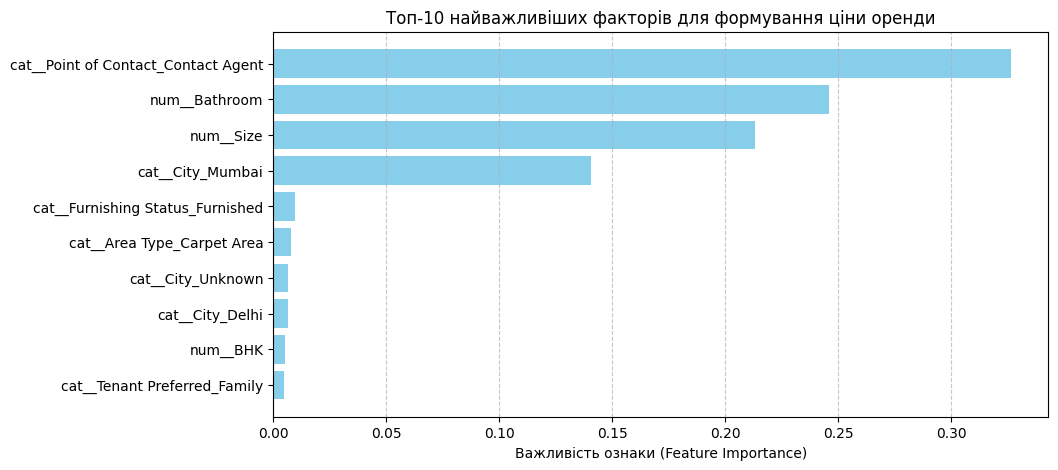

In [35]:
# === ЕКСПЕРИМЕНТ 2: Аналіз важливості ознак ===
import pandas as pd
import matplotlib.pyplot as plt

# 1. Отримуємо важливість кожної ознаки з нашого навченого дерева
importances = tuned_pipeline.named_steps['model'].feature_importances_
feature_names = tuned_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Формуємо DataFrame та сортуємо
feat_imp = pd.DataFrame({'Ознака': feature_names, 'Важливість': importances})
feat_imp = feat_imp.sort_values(by='Важливість', ascending=False).head(10)

# 3. Будуємо графік
plt.figure(figsize=(10, 5))
plt.barh(feat_imp['Ознака'], feat_imp['Важливість'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Топ-10 найважливіших факторів для формування ціни оренди')
plt.xlabel('Важливість ознаки (Feature Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [36]:
# === ЕКСПЕРИМЕНТ 3: Автоматичний підбір гіперпараметрів за допомогою GridSearchCV ===
from sklearn.model_selection import GridSearchCV

# 1. Задаємо сітку параметрів для перевірки
param_grid = {
    'model__max_depth': [4, 6, 8, 10, 12],
    'model__min_samples_split': [5, 10, 15, 20],
    'model__min_samples_leaf': [2, 4, 8]
}

# 2. Налаштовуємо пошук із крос-валідацією (cv=5)
grid_search = GridSearchCV(tuned_pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("=== РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТУ 3 ===")
print(f"Найкращі знайдені параметри: {grid_search.best_params_}")
print(f"Найкращий крос-валідаційний R² Score: {grid_search.best_score_:.4f}")

=== РЕЗУЛЬТАТИ ЕКСПЕРИМЕНТУ 3 ===
Найкращі знайдені параметри: {'model__max_depth': 10, 'model__min_samples_leaf': 8, 'model__min_samples_split': 20}
Найкращий крос-валідаційний R² Score: 0.6897
